Saving CarPrice_Assignment.csv to CarPrice_Assignment (3).csv
R²:   0.8407
RMSE: $3,546


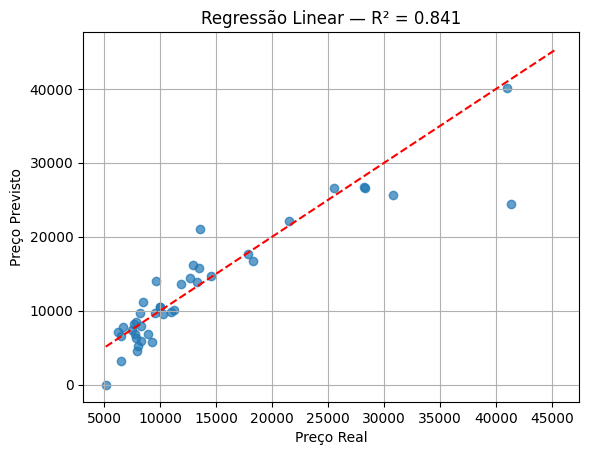

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('CarPrice_Assignment.csv')


for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

X = df.drop(columns=['car_ID', 'price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R²:   {r2:.4f}")
print(f"RMSE: ${rmse:,.0f}")

plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Preço Real')
plt.ylabel('Preço Previsto')
plt.title(f'Regressão Linear — R² = {r2:.3f}')
plt.grid(True)
plt.show()

In [ ]:
#O dataset tinha colunas de texto, como fueltype e carbody, e o modelo só entende números. Então usei o LabelEncoder para transformar cada categoria em um número
#Separei o que o modelo aprende do que ele prevê, X → todas as características do carro (motor, peso, potência)/y → apenas o preço, que é o que queremos prever
#Dividi em Treino e Teste, 80% dos carros para o modelo aprender,20% para testar se ele aprendeu bem
#Treinei o modelo usei o LinearRegression do scikit-learn, que ajusta uma equação matemática relacionando as características ao preço
# Avaliei os resultados Usei duas métricas: R² = 0.84 → o modelo explica 84% da variação de preço, o que é um bom resultado, RMSE = $3.488 → em média o modelo erra $3.488 por carro
